# Static-bin regress-out and motion dRSA

1. **Reliability ceilings.** Movie split-half self-consistency is plotted against the best static-to-dynamic correlation (max over static time). The first panel uses raw population patterns and the second uses RDMs.
2. **Static-bin encoding.** The last-frame static response, averaged over `cfg.static_bin_ms` (120–250 ms by default), predicts the movie population pattern at every movie timepoint. The model is a ridge regression with 5-fold CV across stimuli, and `RidgeCV` picks alpha inside each training fold.
3. **Regress-out.** The same static pattern is removed with in-sample OLS, fit separately at every movie timepoint. The static-to-dynamic matrices are then recomputed as a check.
4. **Motion dRSA.** Movie dRSA with dense optical flow and V-JEPA 2 is computed before and after the regress-out. The question is whether the variance the static pattern leaves unexplained lives in a motion subspace.

In [1]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import yaml

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path('../..').resolve()
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.optical_flow import load_aligned_optical_flow_features
from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
    match_feature_stimulus_names,
)
from project_specific_utils import (
    channel_selection_name, compute_model_rdm_timeseries,
    compute_rdm_timeseries, cross_temporal_similarity,
    cross_temporal_static_dynamic_regression, drsa_lag_profile,
    load_natraster, match_static_dynamic_rasters,
    raw_cross_temporal_similarity, split_half_filename_suffix,
    static_pattern_regress_out, window_mean_responses,
)
from useful_stuff.general_utils import TimeSeries
from useful_stuff.general_utils.utils import mean_centering

In [4]:
@dataclass
class Cfg:
    vid_exp_name: str = "baby1_260716to24" # 'red_20260720to24'
    img_exp_name: str = "baby1_260718to27" #   'red_20260726to27'

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (84,186)
    top_k: int | None = None
    # Intersect good_channels with the image-session reliability config.
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    new_fs: float = 100
    image_crop_ms: int = 1000

    # Saved output of run_static_dynamic_all_frame_timings.py.
    split_half_results_dir: Path | None = None
    split_half_frame_timing: str = 'last_frame'
    split_half_feature_centering: bool = True
    use_spearman_brown: bool = True
    # Static times searched for the best static-to-dynamic correlation.
    static_reference_window_ms: tuple[float, float] = (0, 1000)

    signal_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'correlation'
    # Center channels across stimuli before raw pattern correlations.
    raw_feature_centering: bool = True

    # Static bin [start, end) in ms from image onset that gets regressed out.
    static_bin_ms: tuple[float, float] = (120, 250)

    # Cross-validated ridge from the static bin to every movie timepoint.
    ridge_n_splits: int = 5
    ridge_shuffle: bool = True
    ridge_alphas: tuple[float, ...] = (1e-6, 1e-4, 1e-2, 1, 1e2, 1e4)

    # In-sample regress-out ('lr' is OLS).
    regress_out_type: str = 'lr'
    regress_out_fit_intercept: bool = True

    # Motion models.
    model_features_dir: Path | None = None
    flow_feature_path: Path | None = None
    drop_first_flow_frame: bool = True
    flow_RDM_metric: str = 'cosine_cnt'
    vjepa_model_name: str = 'vjepa2_vitl_fpc64_256'
    model_dataset_name: str = 'static_dynamic'
    vjepa_pooling: str | None = 'mean'
    vjepa_RDM_metric: str = 'cosine_cnt'
    vjepa_example_layer: int = 12

    # Lag profiles are restricted to movie times before the final-frame hold.
    lag_analysis_end_ms: float = 2500
    max_lag_ms: float = 700
    last_frame_onset_ms: float = 2500
    linewidth: float = 2
# EOF


cfg = Cfg()
cfg

Cfg(vid_exp_name='baby1_260716to24', img_exp_name='baby1_260718to27', good_channels=(84, 186), top_k=None, use_reliable_channels=True, reliable_channels_config=None, reliable_channels_key=None, new_fs=100, image_crop_ms=1000, split_half_results_dir=None, split_half_frame_timing='last_frame', split_half_feature_centering=True, use_spearman_brown=True, static_reference_window_ms=(0, 1000), signal_RDM_metric='cosine_cnt', RSA_metric='correlation', raw_feature_centering=True, static_bin_ms=(120, 250), ridge_n_splits=5, ridge_shuffle=True, ridge_alphas=(1e-06, 0.0001, 0.01, 1, 100.0, 10000.0), regress_out_type='lr', regress_out_fit_intercept=True, model_features_dir=None, flow_feature_path=None, drop_first_flow_frame=True, flow_RDM_metric='cosine_cnt', vjepa_model_name='vjepa2_vitl_fpc64_256', model_dataset_name='static_dynamic', vjepa_pooling='mean', vjepa_RDM_metric='cosine_cnt', vjepa_example_layer=12, lag_analysis_end_ms=2500, max_lag_ms=700, last_frame_onset_ms=2500, linewidth=2)

## 1. Movie reliability vs best static-to-dynamic correlation

Both curves come from the saved split-half archive. The black line is the maximum, over static time in `cfg.static_reference_window_ms`, of the static-to-dynamic correlation computed with all movie trials. The orange line is the movie split-half self-consistency (±1 SD across splits).

Loaded /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_all_frame_timings/baby1_260716to24_vs_baby1_260718to27/reliable_channels_84to186/last_frame_rdm_cosine_cnt_feat_cnt_results.npz


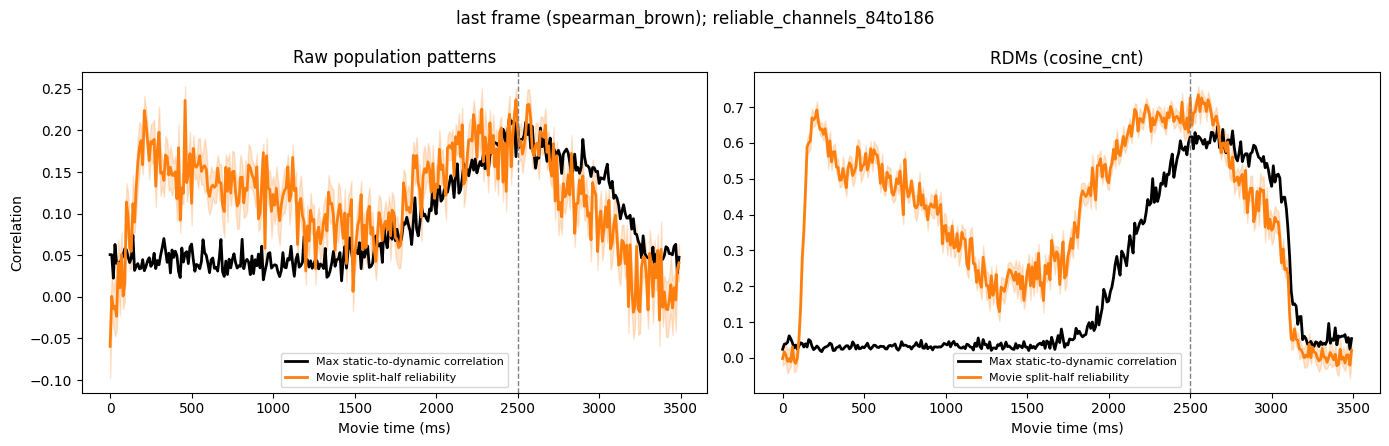

In [5]:
# Resolve the split-half archive for this session pair and channel selection.
channel_selection = channel_selection_name(
    cfg.good_channels, cfg.use_reliable_channels, cfg.top_k,
)
split_half_results_dir = Path(
    cfg.split_half_results_dir
    or PROJECT_ROOT / 'results' / 'static_dynamic_all_frame_timings'
    / f'{cfg.vid_exp_name}_vs_{cfg.img_exp_name}' / channel_selection
).expanduser()
filename_suffix = split_half_filename_suffix(
    cfg.signal_RDM_metric, cfg.split_half_feature_centering,
)
split_half_path = (
    split_half_results_dir
    / f'{cfg.split_half_frame_timing}{filename_suffix}_results.npz'
)
if not split_half_path.is_file():
    raise FileNotFoundError(f'Missing split-half result: {split_half_path}')
# end if not split_half_path.is_file()
with np.load(split_half_path, allow_pickle=False) as archive:
    split_half = {name: archive[name] for name in archive.files}
# end with np.load
if str(split_half['rsa_metric'].item()) != cfg.RSA_metric:
    print(
        f"Warning: archive RSA metric {split_half['rsa_metric'].item()!r} "
        f'differs from cfg.RSA_metric {cfg.RSA_metric!r}.'
    )
# end if RSA metric differs

correction_suffix = 'spearman_brown' if cfg.use_spearman_brown else 'uncorrected'
saved_static_time_ms = split_half['static_times_ms']
saved_dynamic_time_ms = split_half['dynamic_times_ms']
start_ms, end_ms = cfg.static_reference_window_ms
static_reference_mask = (
    (saved_static_time_ms >= start_ms) & (saved_static_time_ms <= end_ms)
)

# analysis -> (best static fit, reliability mean, reliability SD) over movie time.
saved_curves = {}
for analysis in ('raw', 'rsa'):
    lagged_correlation = split_half[
        f'{analysis}_lagged_correlation_all_dynamic_trials'
    ]
    saved_curves[analysis] = (
        np.nanmax(lagged_correlation[:, static_reference_mask], axis=1),
        split_half[f'dynamic_{analysis}_self_consistency_mean_{correction_suffix}'],
        split_half[f'dynamic_{analysis}_self_consistency_std_{correction_suffix}'],
    )
# end for analysis

analysis_titles = {
    'raw': 'Raw population patterns',
    'rsa': f'RDMs ({cfg.signal_RDM_metric})',
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
for axis, analysis in zip(axes, ('raw', 'rsa')):
    best_static_fit, reliability_mean, reliability_std = saved_curves[analysis]
    axis.plot(
        saved_dynamic_time_ms, best_static_fit, color='black',
        linewidth=cfg.linewidth, label='Max static-to-dynamic correlation',
    )
    axis.plot(
        saved_dynamic_time_ms, reliability_mean, color='tab:orange',
        linewidth=cfg.linewidth, label='Movie split-half reliability',
    )
    axis.fill_between(
        saved_dynamic_time_ms,
        reliability_mean - reliability_std,
        reliability_mean + reliability_std,
        color='tab:orange', alpha=0.2,
    )
    axis.axvline(cfg.last_frame_onset_ms, color='grey', linestyle='--', linewidth=1)
    axis.set(title=analysis_titles[analysis], xlabel='Movie time (ms)')
    axis.legend(fontsize=8)
# end for axis, analysis
axes[0].set_ylabel('Correlation')
fig.suptitle(
    f'{cfg.split_half_frame_timing.replace("_", " ")} ({correction_suffix}); '
    f'{channel_selection}'
)
fig.tight_layout()
print(f'Loaded {split_half_path}')

## 2. Load trial-averaged neural responses

The loading and channel selection follow `summary_figs_report.ipynb`, restricted to the last-frame image condition.

In [6]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config or PROJECT_ROOT / 'reliable_channels.yaml'
    )
    # The image-session reliability selection is reused for the movie.
    reliable_channels_key = cfg.reliable_channels_key or cfg.img_exp_name
# end if cfg.use_reliable_channels

data_dir = Path(paths['data_path']) / 'data'
loaded_vid_rasters, vid_stimulus_names, vid_channel_numbers = load_natraster(
    data_dir / f'{cfg.vid_exp_name}_natraster_vid.mat',
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_img_rasters, img_stimulus_names, img_channel_numbers = load_natraster(
    data_dir / f'{cfg.img_exp_name}_natraster_img.mat',
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(img_channel_numbers, vid_channel_numbers):
    raise ValueError('Image and movie sessions retained different channels.')
# end if channel numbers differ

# Keep only last-frame images (img_ prefix) that also exist as movies.
image_rasters, video_rasters, shared_stimuli = match_static_dynamic_rasters(
    loaded_img_rasters, img_stimulus_names,
    loaded_vid_rasters, vid_stimulus_names,
)
# Full movie filenames in matched order; identities such as '4115_11.01'
# contain dots, so they cannot be re-parsed as filenames by the feature matcher.
video_name_by_identity = {
    Path(name).stem.removeprefix('vid_'): name for name in vid_stimulus_names
}
video_names = [video_name_by_identity[identity] for identity in shared_stimuli]

# Optionally rank within the range/reliability-filtered channel pool.
if cfg.top_k is not None:
    channel_scores = video_rasters.max(axis=(1, 2))
    channel_indices = np.argsort(channel_scores)[-cfg.top_k:][::-1]
else:
    channel_indices = np.arange(len(img_channel_numbers))
# end if cfg.top_k is not None
selected_channel_numbers = img_channel_numbers[channel_indices]

# channels x time x stimuli at 1 kHz, then resampled to the analysis grid.
image_ts = TimeSeries(
    image_rasters[channel_indices, :cfg.image_crop_ms, :], fs=1000,
)
video_ts = TimeSeries(video_rasters[channel_indices, :, :], fs=1000)
image_ts.resample(cfg.new_fs)
video_ts.resample(cfg.new_fs)
analysis_fs = video_ts.get_fs()
static_time_ms = np.arange(len(image_ts)) * 1000 / analysis_fs
movie_time_ms = np.arange(len(video_ts)) * 1000 / analysis_fs

print(f'{len(shared_stimuli)} shared stimuli')
print(f'Selected MATLAB channels: {selected_channel_numbers.tolist()}')
print(f'Image {image_ts.shape()}, movie {video_ts.shape()} at {analysis_fs:g} Hz')
if not np.array_equal(selected_channel_numbers, split_half['channel_numbers']):
    print(
        'Warning: the split-half archive used channels '
        f"{split_half['channel_numbers'].tolist()}; rerun "
        'run_static_dynamic_all_frame_timings.py for an exact match.'
    )
# end if channels differ from the archive

100 shared stimuli
Selected MATLAB channels: [101, 102, 103, 104, 105, 106, 107, 108, 109, 121, 122, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 158, 159, 160, 161, 162, 163, 164, 165]
Image (30, 100, 100), movie (30, 350, 100) at 100 Hz


## 3. Ridge encoding of the movie response from the static bin

The predictor is the last-frame image response averaged over `cfg.static_bin_ms` (static channels × stimuli). At every movie timepoint, a separate ridge model maps it to the movie pattern (movie channels × stimuli). Stimuli are split into `cfg.ridge_n_splits` outer folds, and `RidgeCV` picks alpha inside each training fold.

- `corr`: for each held-out stimulus, the correlation between predicted and observed patterns across channels, averaged over stimuli. The channels' shared mean response inflates it.
- `r2`: the held-out R² for each channel across stimuli, averaged over channels. This is the stricter score.

Static bin (120, 250) ms -> samples [12, 25); pattern (30, 100)


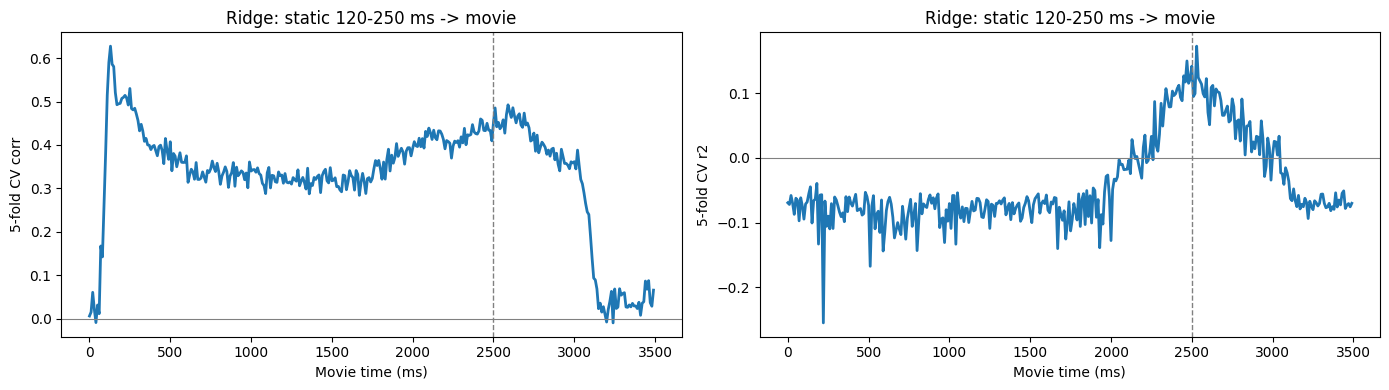

In [7]:
# Mean static response inside [start, end): static channels x stimuli.
static_pattern, (bin_start_index, bin_end_index) = window_mean_responses(
    image_ts.get_array(), cfg.static_bin_ms, analysis_fs,
)
print(
    f'Static bin {cfg.static_bin_ms} ms -> samples '
    f'[{bin_start_index}, {bin_end_index}); pattern {static_pattern.shape}'
)

# A one-sample predictor time axis reuses the cross-temporal regression helper.
static_pattern_ts = TimeSeries(static_pattern[:, np.newaxis, :], fs=analysis_fs)
ridge_scores = {}
for score_type in ('corr', 'r2'):
    # Output is movie time x 1 predictor time; keep the movie-time vector.
    ridge_scores[score_type] = cross_temporal_static_dynamic_regression(
        static_pattern_ts, video_ts,
        regression_type='ridge', cv_type='kf', score_type=score_type,
        n_splits=cfg.ridge_n_splits, shuffle=cfg.ridge_shuffle,
        alphas=cfg.ridge_alphas,
    )[:, 0]
# end for score_type

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
for axis, score_type in zip(axes, ('corr', 'r2')):
    axis.plot(movie_time_ms, ridge_scores[score_type], color='tab:blue', linewidth=cfg.linewidth)
    axis.axhline(0, color='grey', linewidth=0.8)
    axis.axvline(cfg.last_frame_onset_ms, color='grey', linestyle='--', linewidth=1)
    axis.set(
        xlabel='Movie time (ms)', ylabel=f'{cfg.ridge_n_splits}-fold CV {score_type}',
        title=f'Ridge: static {cfg.static_bin_ms[0]:g}-{cfg.static_bin_ms[1]:g} ms -> movie',
    )
# end for axis, score_type
fig.tight_layout()

## 4. Regress the static pattern out of the movie (OLS)

At every movie timepoint, the movie pattern is regressed on the same static pattern with stimuli as samples, and the fitted part is subtracted. The fit is in-sample, so the residual is exactly orthogonal, across stimuli, to every static-bin channel. The regressions only remove what a linear map can explain, and that includes the stimulus-generic mean when `fit_intercept=True`.

Max |residual x static pattern| across stimuli: 5.22e-08


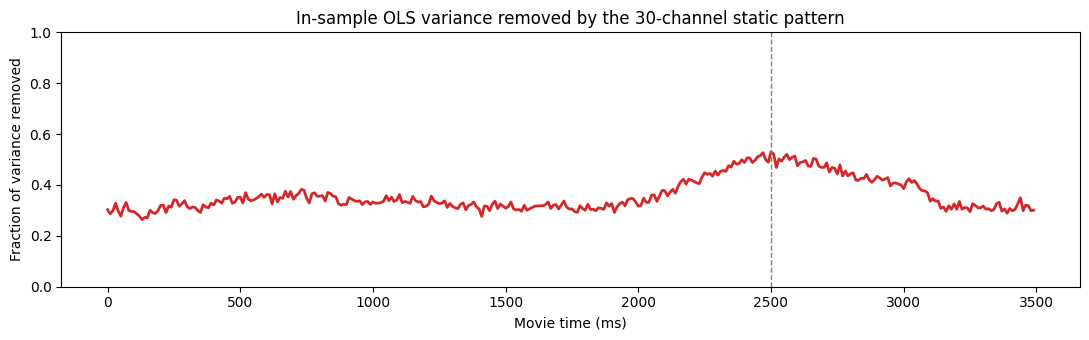

In [8]:
residual_video_ts, regress_out_variance_explained = static_pattern_regress_out(
    static_pattern, video_ts,
    regression_type=cfg.regress_out_type,
    fit_intercept=cfg.regress_out_fit_intercept,
)

# Exact check: residual x centered static pattern should vanish at every time.
centered_static_pattern = static_pattern - static_pattern.mean(axis=1, keepdims=True)
max_cross_covariance = np.abs(np.einsum(
    'cts,ks->ctk', residual_video_ts.get_array(), centered_static_pattern,
)).max()
print(f'Max |residual x static pattern| across stimuli: {max_cross_covariance:.2e}')

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(movie_time_ms, regress_out_variance_explained, color='tab:red', linewidth=cfg.linewidth)
ax.axvline(cfg.last_frame_onset_ms, color='grey', linestyle='--', linewidth=1)
ax.set(
    xlabel='Movie time (ms)', ylabel='Fraction of variance removed',
    title=f'In-sample OLS variance removed by the {len(selected_channel_numbers)}-channel static pattern',
    ylim=(0, 1),
)
fig.tight_layout()

### Check: static-to-dynamic correlation after the regress-out

The cross-temporal matrices use the same definitions as the split-half archive (raw pattern correlation per stimulus, and RDM correlation), computed here from the trial-averaged responses. Orthogonality across stimuli does not force either measure to zero. Expect a reduction concentrated on the static-bin columns (dashed lines), not an exact null. The last panel refits the CV ridge on the residual.

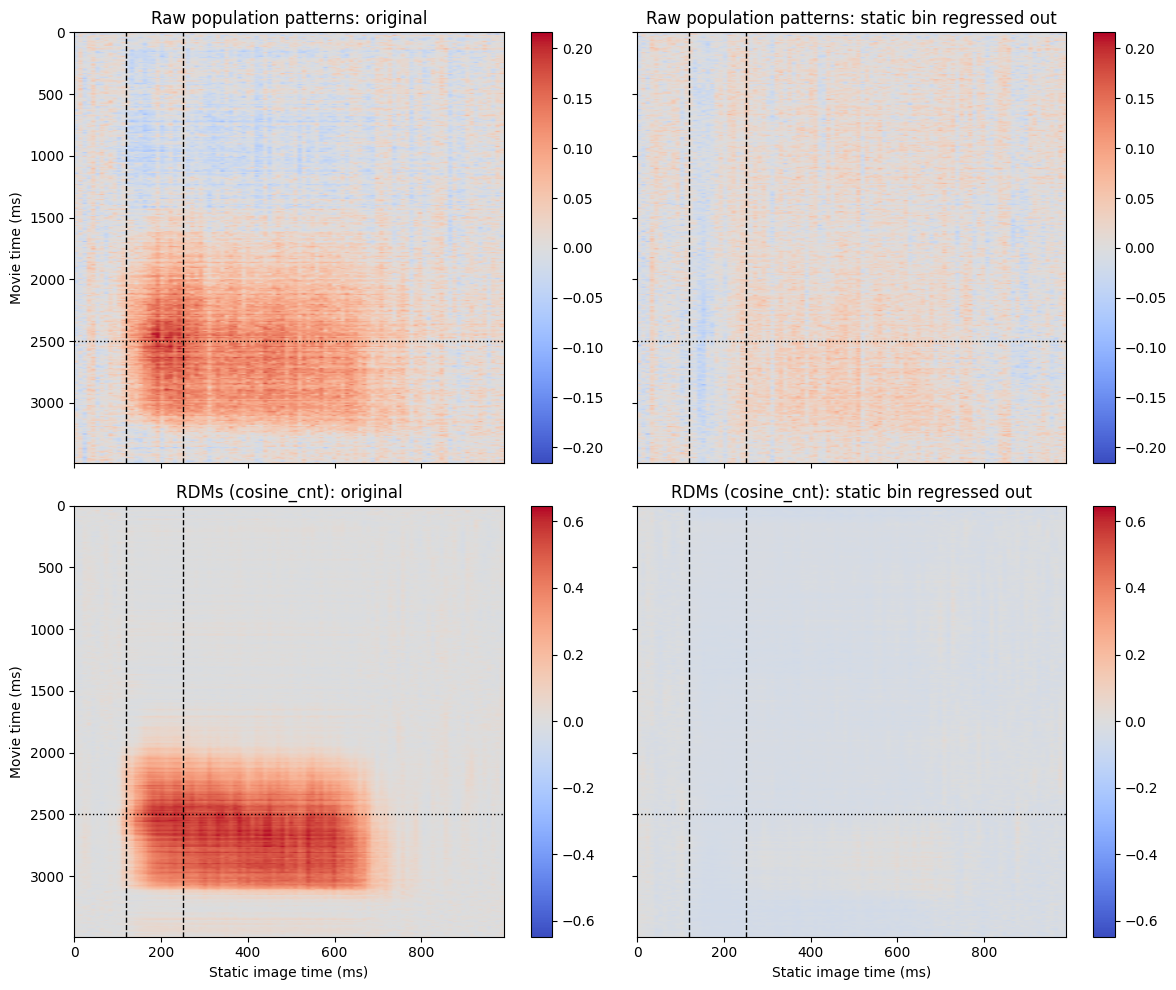

In [9]:
movie_conditions = {
    'original': video_ts,
    'static bin regressed out': residual_video_ts,
}
static_array = image_ts.get_array()
static_raw = mean_centering(static_array, axis=2) if cfg.raw_feature_centering else static_array
static_rdms = compute_rdm_timeseries(static_array, cfg.signal_RDM_metric)

# condition -> movie neural RDMs (movie time x stimulus pairs), reused in section 5.
movie_rdms = {}
# condition -> analysis -> movie time x static time similarity.
cross_temporal = {}
for condition_name, movie_ts in movie_conditions.items():
    movie_array = movie_ts.get_array()
    movie_raw = mean_centering(movie_array, axis=2) if cfg.raw_feature_centering else movie_array
    movie_rdms[condition_name] = compute_rdm_timeseries(movie_array, cfg.signal_RDM_metric)
    cross_temporal[condition_name] = {
        'raw': raw_cross_temporal_similarity(movie_raw, static_raw),
        'rsa': cross_temporal_similarity(
            movie_rdms[condition_name], static_rdms, cfg.RSA_metric,
        ),
    }
# end for condition_name, movie_ts

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
for row, analysis in enumerate(('raw', 'rsa')):
    color_limit = np.nanmax(np.abs(cross_temporal['original'][analysis]))
    for column, condition_name in enumerate(movie_conditions):
        axis = axes[row, column]
        image = axis.imshow(
            cross_temporal[condition_name][analysis], aspect='auto', cmap='coolwarm',
            vmin=-color_limit, vmax=color_limit,
            extent=(static_time_ms[0], static_time_ms[-1], movie_time_ms[-1], movie_time_ms[0]),
        )
        for bin_edge_ms in cfg.static_bin_ms:
            axis.axvline(bin_edge_ms, color='black', linestyle='--', linewidth=1)
        # end for bin_edge_ms
        axis.axhline(cfg.last_frame_onset_ms, color='black', linestyle=':', linewidth=1)
        axis.set_title(f'{analysis_titles[analysis]}: {condition_name}')
        fig.colorbar(image, ax=axis)
    # end for column, condition_name
    axes[row, 0].set_ylabel('Movie time (ms)')
# end for row, analysis
for axis in axes[1]:
    axis.set_xlabel('Static image time (ms)')
# end for axis
fig.tight_layout()

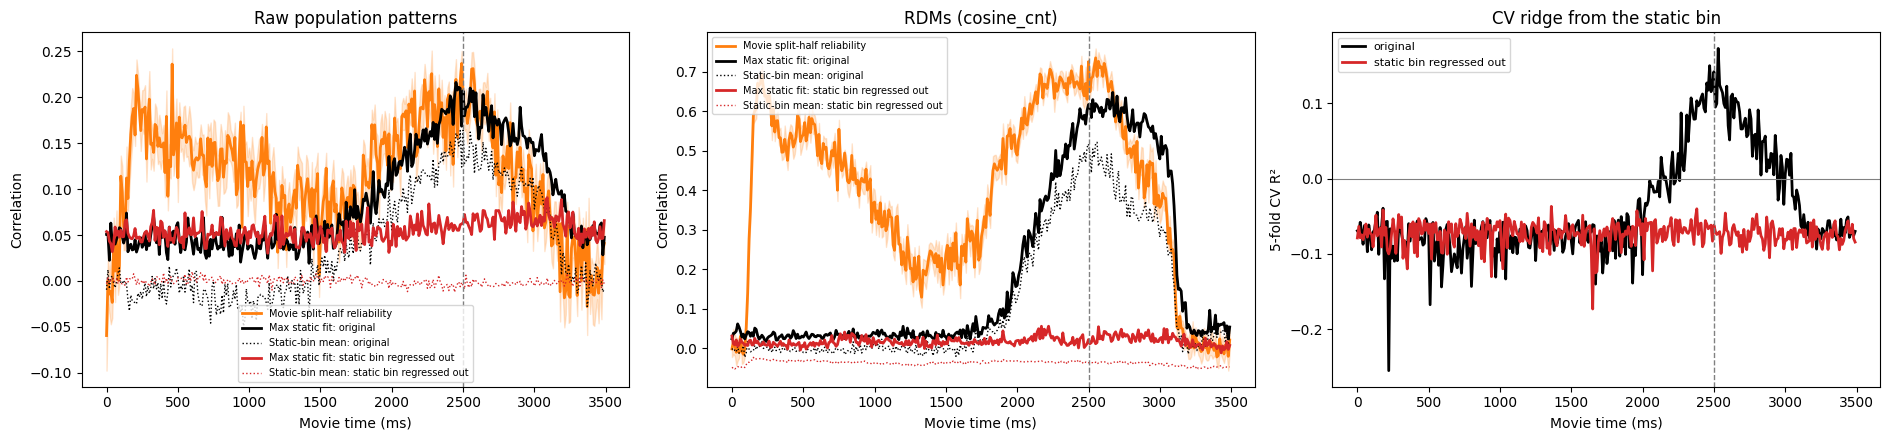

In [10]:
static_window_mask = (static_time_ms >= start_ms) & (static_time_ms <= end_ms)
static_bin_mask = (
    (static_time_ms >= static_time_ms[bin_start_index])
    & (static_time_ms <= static_time_ms[bin_end_index - 1])
)

fig, axes = plt.subplots(1, 3, figsize=(19, 4.5), sharex=True)
for axis, analysis in zip(axes[:2], ('raw', 'rsa')):
    _, reliability_mean, reliability_std = saved_curves[analysis]
    axis.plot(saved_dynamic_time_ms, reliability_mean, color='tab:orange', linewidth=cfg.linewidth, label='Movie split-half reliability')
    axis.fill_between(
        saved_dynamic_time_ms, reliability_mean - reliability_std,
        reliability_mean + reliability_std, color='tab:orange', alpha=0.2,
    )
    for condition_name, color in zip(movie_conditions, ('black', 'tab:red')):
        similarity = cross_temporal[condition_name][analysis]
        axis.plot(
            movie_time_ms, np.nanmax(similarity[:, static_window_mask], axis=1),
            color=color, linewidth=cfg.linewidth, label=f'Max static fit: {condition_name}',
        )
        axis.plot(
            movie_time_ms, np.nanmean(similarity[:, static_bin_mask], axis=1),
            color=color, linewidth=1, linestyle=':', label=f'Static-bin mean: {condition_name}',
        )
    # end for condition_name, color
    axis.axvline(cfg.last_frame_onset_ms, color='grey', linestyle='--', linewidth=1)
    axis.set(title=analysis_titles[analysis], xlabel='Movie time (ms)', ylabel='Correlation')
    axis.legend(fontsize=7)
# end for axis, analysis

# The CV ridge on the residual should be at or below zero.
residual_ridge_r2 = cross_temporal_static_dynamic_regression(
    static_pattern_ts, residual_video_ts,
    regression_type='ridge', cv_type='kf', score_type='r2',
    n_splits=cfg.ridge_n_splits, shuffle=cfg.ridge_shuffle,
    alphas=cfg.ridge_alphas,
)[:, 0]
axes[2].plot(movie_time_ms, ridge_scores['r2'], color='black', linewidth=cfg.linewidth, label='original')
axes[2].plot(movie_time_ms, residual_ridge_r2, color='tab:red', linewidth=cfg.linewidth, label='static bin regressed out')
axes[2].axhline(0, color='grey', linewidth=0.8)
axes[2].axvline(cfg.last_frame_onset_ms, color='grey', linestyle='--', linewidth=1)
axes[2].set(title='CV ridge from the static bin', xlabel='Movie time (ms)', ylabel=f'{cfg.ridge_n_splits}-fold CV R²')
axes[2].legend(fontsize=8)
fig.tight_layout()

## 5. Motion dRSA before and after the regress-out

The model RDMs are computed once per source frame and upsampled to the neural grid. Only the neural RDMs change between the two conditions.

- **Optical flow:** dense Farneback (u, v) fields. The undefined first frame is dropped, and the resulting model-time offset is kept in the lag axis.
- **V-JEPA 2:** every extracted layer, from causal sliding-window features.

If the residual is mostly motion, its dRSA with these models should stay close to the original, or rise, even though the static bin removes a large share of the variance.

In [11]:
model_features_dir = Path(cfg.model_features_dir or Path(paths['data_path']) / 'models').expanduser()

# Optical flow: features x frames x stimuli, first (all-zero) frame dropped.
flow_feature_path = Path(
    cfg.flow_feature_path or model_features_dir / 'optical_flow_farneback_static_dynamic.h5'
).expanduser()
flow_movie_names = match_feature_stimulus_names(flow_feature_path, video_names)
flow_features, flow_fs, flow_metadata = load_aligned_optical_flow_features(
    flow_feature_path, flow_movie_names, drop_first_frame=cfg.drop_first_flow_frame,
)
if flow_metadata['zero_flow_policy'] != 'linear_internal_interpolation':
    raise RuntimeError('Rerun run_optical_flow_extraction.py to repair zero-flow runs.')
# end if zero_flow_policy
flow_time_offset_ms = flow_metadata['first_valid_flow_time_s'] * 1000
flow_rdms = compute_model_rdm_timeseries(flow_features, flow_fs, analysis_fs, cfg.flow_RDM_metric)
del flow_features

# condition -> movie neural time x flow time dRSA.
flow_drsa = {
    condition_name: cross_temporal_similarity(movie_rdms[condition_name], flow_rdms, cfg.RSA_metric)
    for condition_name in movie_conditions
}
print(f'Optical flow RDMs {flow_rdms.shape} (time x pairs), offset {flow_time_offset_ms:.2f} ms')

# V-JEPA 2: one RDM timecourse per layer, shallow to deep.
vjepa_feature_paths = list_video_feature_files(
    model_features_dir, cfg.vjepa_model_name, cfg.model_dataset_name, cfg.vjepa_pooling,
)
vjepa_movie_names = match_feature_stimulus_names(vjepa_feature_paths[0], video_names)
vjepa_layer_names = []
# condition -> list over layers of movie neural time x model time dRSA.
vjepa_drsa = {condition_name: [] for condition_name in movie_conditions}
for feature_path in vjepa_feature_paths:
    layer_features, layer_name, layer_fs = load_aligned_video_features(
        feature_path, vjepa_movie_names, frame_index=None,
    )
    layer_rdms = compute_model_rdm_timeseries(layer_features, layer_fs, analysis_fs, cfg.vjepa_RDM_metric)
    for condition_name in movie_conditions:
        vjepa_drsa[condition_name].append(
            cross_temporal_similarity(movie_rdms[condition_name], layer_rdms, cfg.RSA_metric)
        )
    # end for condition_name
    vjepa_layer_names.append(layer_name)
# end for feature_path
vjepa_drsa = {name: np.stack(matrices) for name, matrices in vjepa_drsa.items()}
print(f'V-JEPA 2 dRSA {vjepa_drsa["original"].shape} (layers, neural time, model time)')

Optical flow RDMs (298, 4950) (time x pairs), offset 16.67 ms
V-JEPA 2 dRSA (24, 350, 300) (layers, neural time, model time)


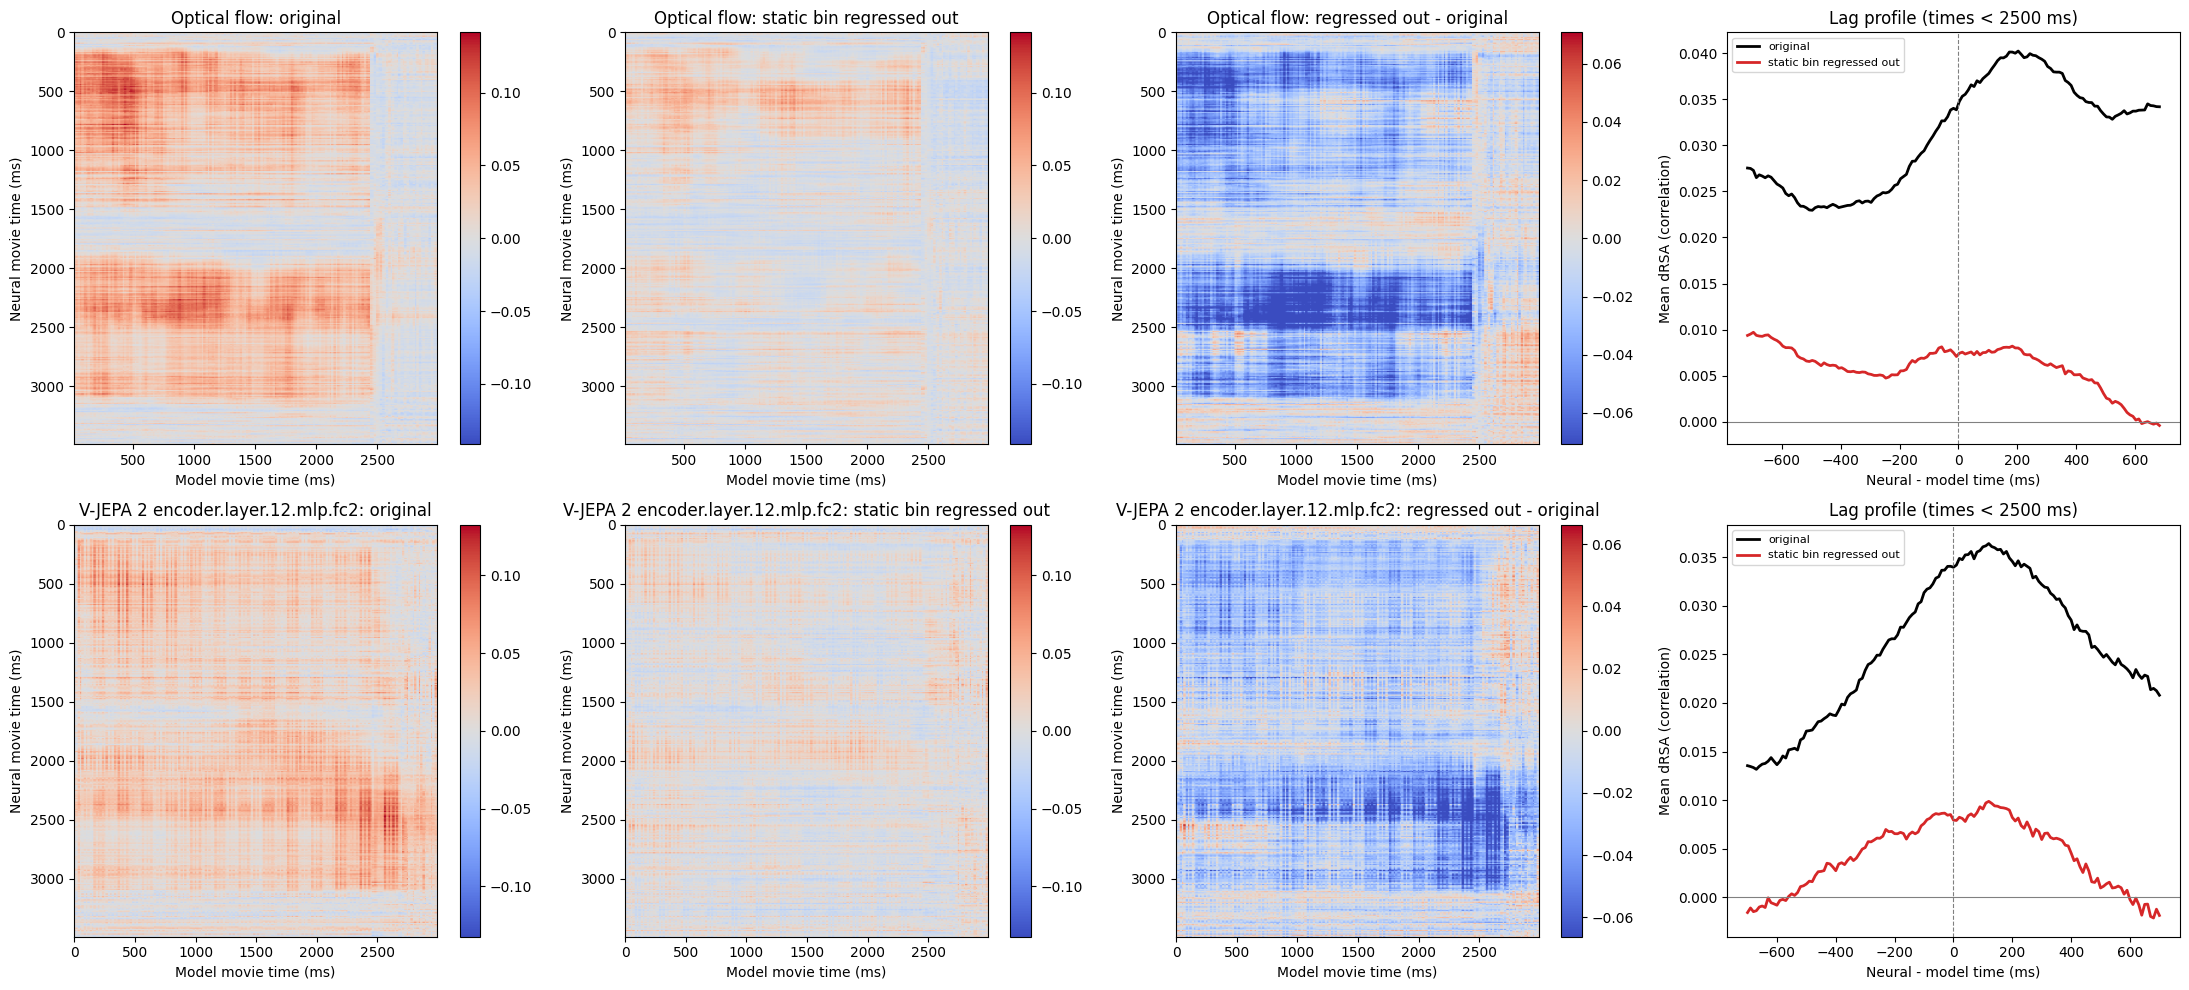

In [12]:
# label -> (condition -> dRSA matrix, model time offset in ms).
example_models = {
    'Optical flow': (flow_drsa, flow_time_offset_ms),
    f'V-JEPA 2 {vjepa_layer_names[cfg.vjepa_example_layer]}': (
        {name: matrices[cfg.vjepa_example_layer] for name, matrices in vjepa_drsa.items()},
        0.0,
    ),
}

fig, axes = plt.subplots(len(example_models), 4, figsize=(22, 5 * len(example_models)))
for row, (model_label, (drsa_by_condition, time_offset_ms)) in enumerate(example_models.items()):
    original_matrix = drsa_by_condition['original']
    residual_matrix = drsa_by_condition['static bin regressed out']
    model_time_ms = time_offset_ms + np.arange(original_matrix.shape[1]) * 1000 / analysis_fs
    extent = (model_time_ms[0], model_time_ms[-1], movie_time_ms[-1], movie_time_ms[0])
    color_limit = np.nanmax(np.abs(original_matrix))
    panels = (
        ('original', original_matrix, color_limit),
        ('static bin regressed out', residual_matrix, color_limit),
        ('regressed out - original', residual_matrix - original_matrix, color_limit / 2),
    )
    for axis, (panel_title, matrix, limit) in zip(axes[row, :3], panels):
        image = axis.imshow(matrix, aspect='auto', cmap='coolwarm', vmin=-limit, vmax=limit, extent=extent)
        axis.set(title=f'{model_label}: {panel_title}', xlabel='Model movie time (ms)', ylabel='Neural movie time (ms)')
        fig.colorbar(image, ax=axis)
    # end for axis, panel

    for condition_name, color in zip(movie_conditions, ('black', 'tab:red')):
        lag_ms, lag_profile = drsa_lag_profile(
            drsa_by_condition[condition_name], analysis_fs,
            cfg.lag_analysis_end_ms, cfg.max_lag_ms, time_offset_ms,
        )
        axes[row, 3].plot(lag_ms, lag_profile, color=color, linewidth=cfg.linewidth, label=condition_name)
    # end for condition_name, color
    axes[row, 3].axhline(0, color='grey', linewidth=0.8)
    axes[row, 3].axvline(0, color='grey', linestyle='--', linewidth=0.8)
    axes[row, 3].set(
        title=f'Lag profile (times < {cfg.lag_analysis_end_ms:g} ms)',
        xlabel='Neural - model time (ms)', ylabel=f'Mean dRSA ({cfg.RSA_metric})',
    )
    axes[row, 3].legend(fontsize=8)
# end for row, model
fig.tight_layout()

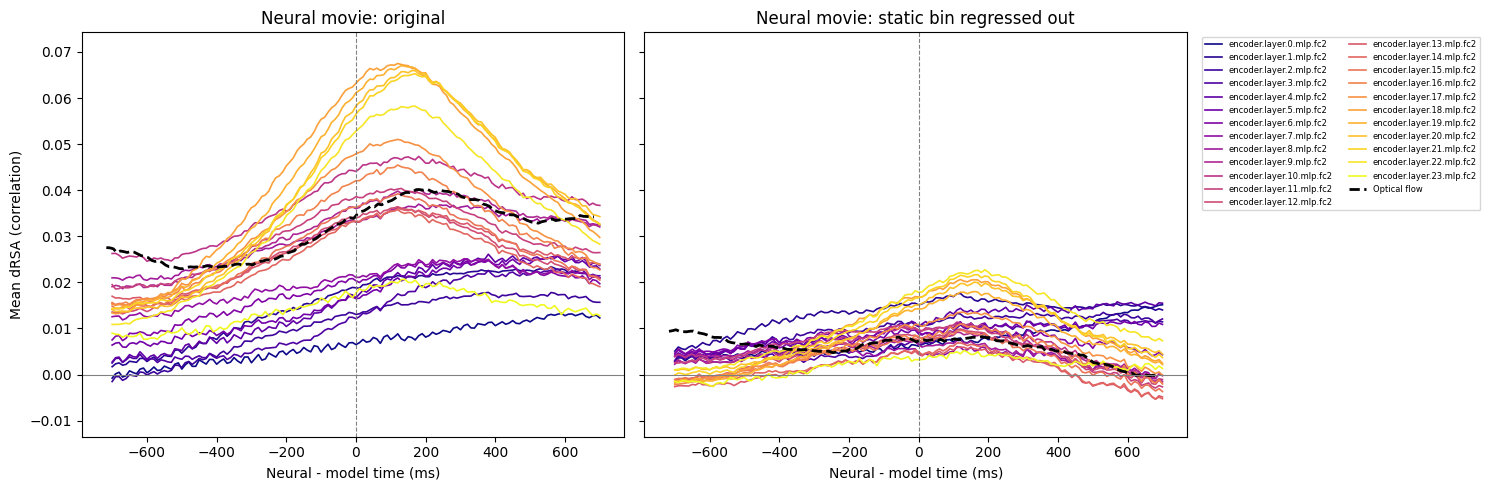

In [13]:
# Lag profiles for every V-JEPA 2 layer and optical flow, before vs after.
layer_colors = plt.cm.plasma(np.linspace(0, 1, len(vjepa_layer_names)))
# condition -> layers x lags, and condition -> flow lag profile.
vjepa_lag_profiles = {}
flow_lag_profiles = {}
for condition_name in movie_conditions:
    layer_profiles = []
    for layer_matrix in vjepa_drsa[condition_name]:
        vjepa_lag_ms, lag_profile = drsa_lag_profile(
            layer_matrix, analysis_fs, cfg.lag_analysis_end_ms, cfg.max_lag_ms,
        )
        layer_profiles.append(lag_profile)
    # end for layer_matrix
    vjepa_lag_profiles[condition_name] = np.stack(layer_profiles)
    flow_lag_ms, flow_lag_profiles[condition_name] = drsa_lag_profile(
        flow_drsa[condition_name], analysis_fs, cfg.lag_analysis_end_ms,
        cfg.max_lag_ms, flow_time_offset_ms,
    )
# end for condition_name

profile_limit = np.nanmax(np.abs(np.concatenate([
    profiles.ravel() for profiles in vjepa_lag_profiles.values()
])))
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for axis, condition_name in zip(axes, movie_conditions):
    for layer_index, layer_name in enumerate(vjepa_layer_names):
        axis.plot(
            vjepa_lag_ms, vjepa_lag_profiles[condition_name][layer_index],
            color=layer_colors[layer_index], linewidth=1.2, label=layer_name,
        )
    # end for layer_index, layer_name
    axis.plot(
        flow_lag_ms, flow_lag_profiles[condition_name], color='black',
        linewidth=cfg.linewidth, linestyle='--', label='Optical flow',
    )
    axis.axhline(0, color='grey', linewidth=0.8)
    axis.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    axis.set(title=f'Neural movie: {condition_name}', xlabel='Neural - model time (ms)', ylim=(-0.2 * profile_limit, 1.1 * profile_limit))
# end for axis, condition_name
axes[0].set_ylabel(f'Mean dRSA ({cfg.RSA_metric})')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=6, ncol=2)
fig.tight_layout()

Mean movie variance removed by the static bin: 0.360
Optical flow peak dRSA retained: 0.241
  encoder.layer.0.mlp.fc2: 0.013 -> 0.015 (ratio 1.14)
  encoder.layer.1.mlp.fc2: 0.023 -> 0.018 (ratio 0.75)
  encoder.layer.2.mlp.fc2: 0.018 -> 0.013 (ratio 0.76)
  encoder.layer.3.mlp.fc2: 0.023 -> 0.012 (ratio 0.53)
  encoder.layer.4.mlp.fc2: 0.026 -> 0.016 (ratio 0.60)
  encoder.layer.5.mlp.fc2: 0.026 -> 0.012 (ratio 0.45)
  encoder.layer.6.mlp.fc2: 0.025 -> 0.011 (ratio 0.46)
  encoder.layer.7.mlp.fc2: 0.025 -> 0.006 (ratio 0.24)
  encoder.layer.8.mlp.fc2: 0.037 -> 0.008 (ratio 0.21)
  encoder.layer.9.mlp.fc2: 0.040 -> 0.009 (ratio 0.23)
  encoder.layer.10.mlp.fc2: 0.047 -> 0.011 (ratio 0.24)
  encoder.layer.11.mlp.fc2: 0.040 -> 0.011 (ratio 0.27)
  encoder.layer.12.mlp.fc2: 0.036 -> 0.010 (ratio 0.27)
  encoder.layer.13.mlp.fc2: 0.036 -> 0.006 (ratio 0.17)
  encoder.layer.14.mlp.fc2: 0.036 -> 0.007 (ratio 0.19)
  encoder.layer.15.mlp.fc2: 0.039 -> 0.010 (ratio 0.25)
  encoder.layer.16.mlp

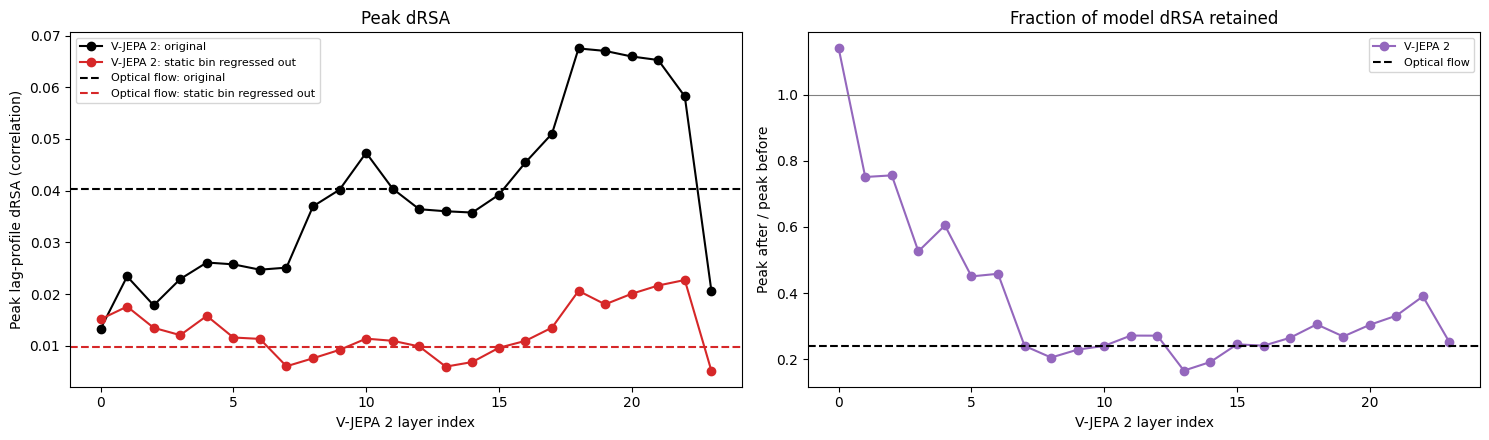

In [14]:
# Peak of each lag profile, and how much of it survives the regress-out.
peak_before = np.nanmax(vjepa_lag_profiles['original'], axis=1)
peak_after = np.nanmax(vjepa_lag_profiles['static bin regressed out'], axis=1)
flow_peak_before = np.nanmax(flow_lag_profiles['original'])
flow_peak_after = np.nanmax(flow_lag_profiles['static bin regressed out'])
layer_indices = np.arange(len(vjepa_layer_names))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].plot(layer_indices, peak_before, 'o-', color='black', label='V-JEPA 2: original')
axes[0].plot(layer_indices, peak_after, 'o-', color='tab:red', label='V-JEPA 2: static bin regressed out')
axes[0].axhline(flow_peak_before, color='black', linestyle='--', label='Optical flow: original')
axes[0].axhline(flow_peak_after, color='tab:red', linestyle='--', label='Optical flow: static bin regressed out')
axes[0].set(xlabel='V-JEPA 2 layer index', ylabel=f'Peak lag-profile dRSA ({cfg.RSA_metric})', title='Peak dRSA')
axes[0].legend(fontsize=8)

axes[1].plot(layer_indices, peak_after / peak_before, 'o-', color='tab:purple', label='V-JEPA 2')
axes[1].axhline(flow_peak_after / flow_peak_before, color='black', linestyle='--', label='Optical flow')
axes[1].axhline(1, color='grey', linewidth=0.8)
axes[1].set(xlabel='V-JEPA 2 layer index', ylabel='Peak after / peak before', title='Fraction of model dRSA retained')
axes[1].legend(fontsize=8)
fig.tight_layout()

print(f'Mean movie variance removed by the static bin: {np.mean(regress_out_variance_explained):.3f}')
print(f'Optical flow peak dRSA retained: {flow_peak_after / flow_peak_before:.3f}')
for layer_name, before, after in zip(vjepa_layer_names, peak_before, peak_after):
    print(f'  {layer_name}: {before:.3f} -> {after:.3f} (ratio {after / before:.2f})')
# end for layer_name